In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('List of Countries by Sugarcane Production.csv')
data.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


## Understanding the data

In [3]:
data.shape

(103, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Unnamed: 0                  103 non-null    int64 
 1   Country                     103 non-null    object
 2   Continent                   103 non-null    object
 3   Production (Tons)           103 non-null    object
 4   Production per Person (Kg)  103 non-null    object
 5   Acreage (Hectare)           102 non-null    object
 6   Yield (Kg / Hectare)        102 non-null    object
dtypes: int64(1), object(6)
memory usage: 5.8+ KB


In [5]:
data.isna().sum()

Unnamed: 0                    0
Country                       0
Continent                     0
Production (Tons)             0
Production per Person (Kg)    0
Acreage (Hectare)             1
Yield (Kg / Hectare)          1
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

# DataCleaning

In [7]:
# Removing the Unwanted column
data.drop('Unnamed: 0',axis=1,inplace=True)

In [8]:
data.head()

,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [9]:
data['Production (Tons)'] = data['Production (Tons)'].str.replace('.','')
data['Production per Person (Kg)'] = data['Production per Person (Kg)'].str.replace('.','').str.replace(',','')
data['Acreage (Hectare)'] = data['Acreage (Hectare)'].str.replace('.','')
data['Yield (Kg / Hectare)'] = data['Yield (Kg / Hectare)'].str.replace('.','').str.replace(',','.')

In [10]:
data.head()

,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,Brazil,South America,768678382,3668531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [11]:
data.rename(columns={'Production (Tons)':'Production(Tons)'},inplace=True)
data.rename(columns={'Production per Person (Kg)':'Production_per_Person(Kg)'},inplace=True)
data.rename(columns={'Acreage (Hectare)':'Acreage(Hectare)'},inplace=True)
data.rename(columns={'Yield (Kg / Hectare)':'Yield(Kg/Hectare)'},inplace=True)

In [12]:
data.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [13]:
# Removing null values
data[data['Yield(Kg/Hectare)'].isna()]

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,Djibouti,Africa,53,51,NaN,NaN


In [14]:
data = data.dropna().reset_index().drop('index',axis=1)

In [15]:
data.isna().sum()
data.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [16]:
data['Production(Tons)'] = data['Production(Tons)'].astype(float)
data['Production_per_Person(Kg)'] = data['Production_per_Person(Kg)'].astype(float)
data['Acreage(Hectare)'] = data['Acreage(Hectare)'].astype(float)
data['Yield(Kg/Hectare)'] = data['Yield(Kg/Hectare)'].astype(float)

In [17]:
data.dtypes

Country                       object
Continent                     object
Production(Tons)             float64
Production_per_Person(Kg)    float64
Acreage(Hectare)             float64
Yield(Kg/Hectare)            float64
dtype: object

# Univariate Analysis

In [18]:
data.describe()

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,1.020000e+02,1.020000e+02,1.020000e+02,102.000000
mean,1.850372e+07,4.124805e+05,2.498981e+05,52628.078431
std,8.419149e+07,8.669140e+05,1.137003e+06,30504.676683
min,1.000000e+00,0.000000e+00,0.000000e+00,10.000000
25%,6.251875e+04,1.075225e+04,1.104000e+03,29072.025000
50%,1.440044e+06,8.135850e+04,1.655800e+04,54108.950000
75%,6.426824e+06,2.828128e+05,8.047400e+04,73282.700000
max,7.686784e+08,4.816299e+06,1.022620e+07,129049.300000


**1.How Many Countries Produce Sugarcane from Each Continent?**

In [19]:
data.nunique()

Country                      102
Continent                      6
Production(Tons)             102
Production_per_Person(Kg)    101
Acreage(Hectare)             101
Yield(Kg/Hectare)            102
dtype: int64

<Axes: xlabel='Continent'>

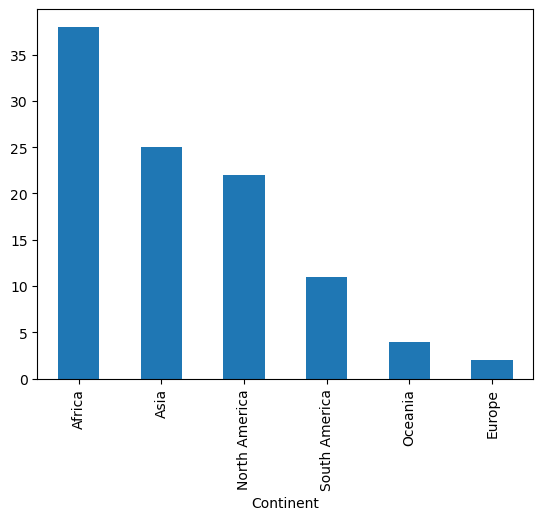

In [20]:
data['Continent'].value_counts().plot(kind='bar')

In [21]:
data.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668531.0,10226205.0,75167.5
1,India,Asia,348448000.0,260721.0,4950000.0,70393.5
2,China,Asia,123059739.0,88287.0,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264303.0,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.0,1130820.0,57879.0


# Outliers 

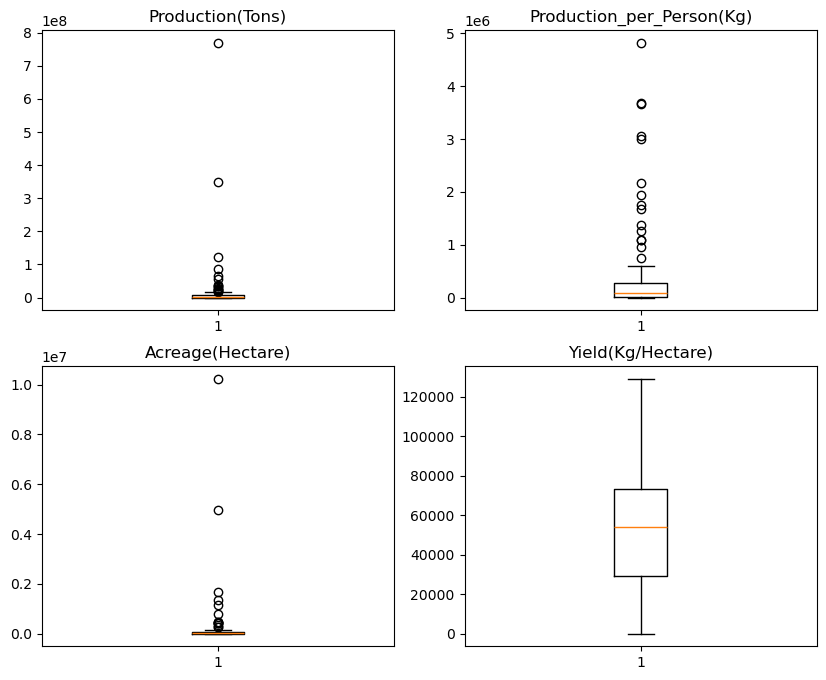

In [22]:
fig = plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.boxplot(data['Production(Tons)'])
plt.title('Production(Tons)')

plt.subplot(2,2,2)
plt.boxplot(data['Production_per_Person(Kg)'])
plt.title('Production_per_Person(Kg)')

plt.subplot(2,2,3)
plt.boxplot(data['Acreage(Hectare)'])
plt.title('Acreage(Hectare)')

plt.subplot(2,2,4)
plt.boxplot(data['Yield(Kg/Hectare)'])
plt.title('Yield(Kg/Hectare)')
plt.show()

# Data Distribution

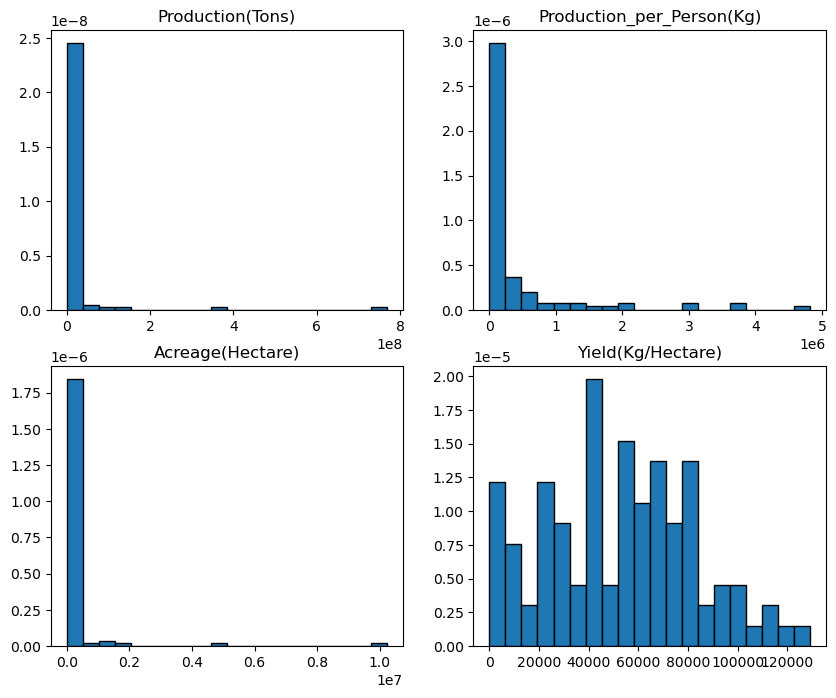

In [23]:
fig = plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.hist(data['Production(Tons)'],density=True,bins=20,edgecolor='black')
plt.title('Production(Tons)')

plt.subplot(2,2,2)
plt.hist(data['Production_per_Person(Kg)'],density=True,bins=20,edgecolor='black')
plt.title('Production_per_Person(Kg)')

plt.subplot(2,2,3)
plt.hist(data['Acreage(Hectare)'],density=True,bins=20,edgecolor='black')
plt.title('Acreage(Hectare)')

plt.subplot(2,2,4)
plt.hist(data['Yield(Kg/Hectare)'],density=True,bins=20,edgecolor='black')
plt.title('Yield(Kg/Hectare)')
plt.show()

# Bivariate analysis

In [24]:
new_df = data[['Country','Production(Tons)']]  
new_df['Production(Tons)_Percentage'] = new_df['Production(Tons)']*100/new_df['Production(Tons)'].sum()
new_df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18760\1650360629.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['Production(Tons)_Percentage'] = new_df['Production(Tons)']*100/new_df['Production(Tons)'].sum()


,Country,Production(Tons),Production(Tons)_Percentage
0,Brazil,768678382.0,40.727285
1,India,348448000.0,18.462001
2,China,123059739.0,6.520138
3,Thailand,87468496.0,4.634389
4,Pakistan,65450704.0,3.467809


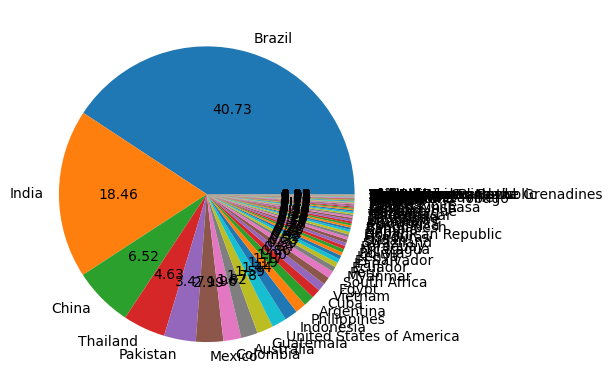

In [25]:
plt.pie(new_df['Production(Tons)'],labels=new_df['Country'],autopct='%.2f')
plt.show()

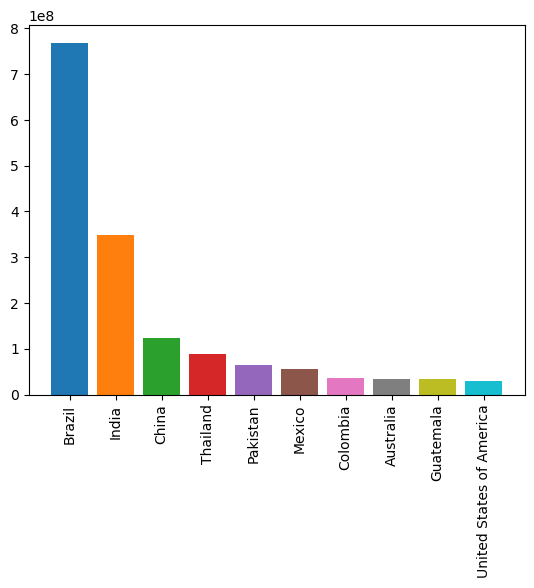

In [26]:
# Generating Random colors
import numpy as np
colors = plt.cm.tab10(np.linspace(0,1,10))

# Ploting Bar
plt.bar(x=data['Country'].head(10),height=data['Production(Tons)'].head(10),color=colors)
plt.xticks(rotation=90)
plt.show()

**Which country is using the highest Land?**

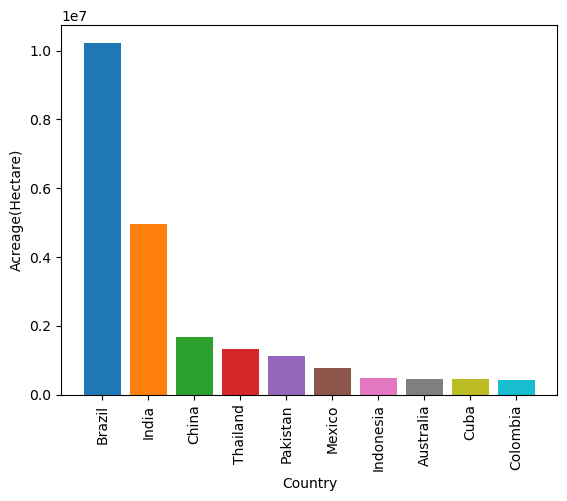

In [27]:
plt.bar(x=data.sort_values('Acreage(Hectare)',ascending=False)['Country'].head(10),height=data.sort_values('Acreage(Hectare)',ascending=False)['Acreage(Hectare)'].head(10),color=colors)
plt.xlabel('Country')
plt.ylabel('Acreage(Hectare)')
plt.xticks(rotation=90)
plt.show()

**Which country has the highest Yield per Hectare**

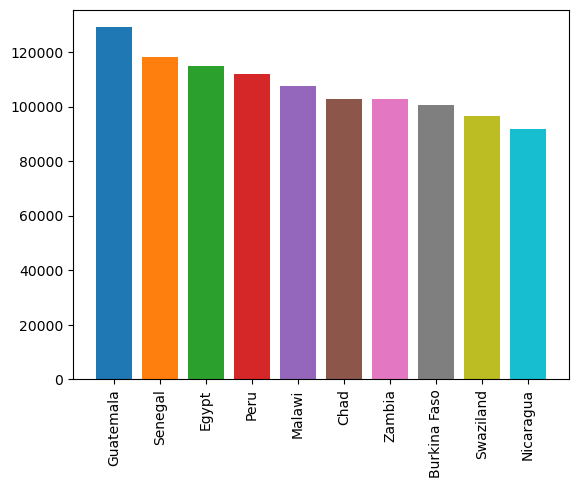

In [28]:
plt.bar(x=data.sort_values('Yield(Kg/Hectare)',ascending=False)['Country'].head(10),height=data.sort_values('Yield(Kg/Hectare)',ascending=False)['Yield(Kg/Hectare)'].head(10),color=colors)
plt.xticks(rotation=90)
plt.show()

**Which Country Has the Highest Production per Person?**

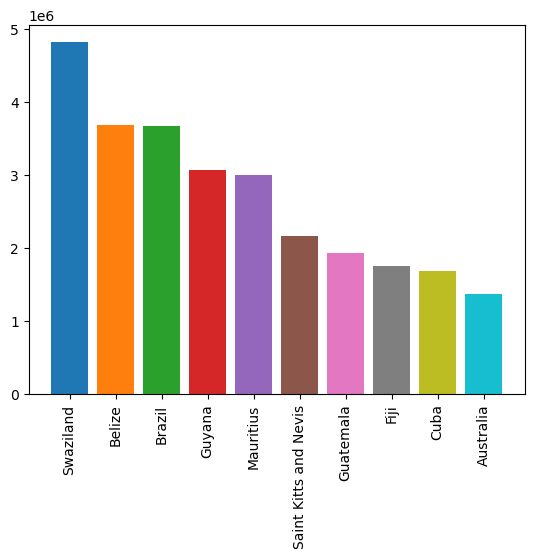

In [29]:
plt.bar(x=data.sort_values('Production_per_Person(Kg)',ascending=False)['Country'].head(10),height=data.sort_values('Production_per_Person(Kg)',ascending=False)['Production_per_Person(Kg)'].head(10),color=colors)
plt.xticks(rotation=90)
plt.show()

**Correlation Analysis**

In [30]:
corr = data[['Production(Tons)','Production_per_Person(Kg)','Acreage(Hectare)','Yield(Kg/Hectare)']].corr()
corr

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Production(Tons),1.000000,0.352369,0.997550,0.132812
Production_per_Person(Kg),0.352369,1.000000,0.341974,0.220522
Acreage(Hectare),0.997550,0.341974,1.000000,0.113433
Yield(Kg/Hectare),0.132812,0.220522,0.113433,1.000000


<Axes: >

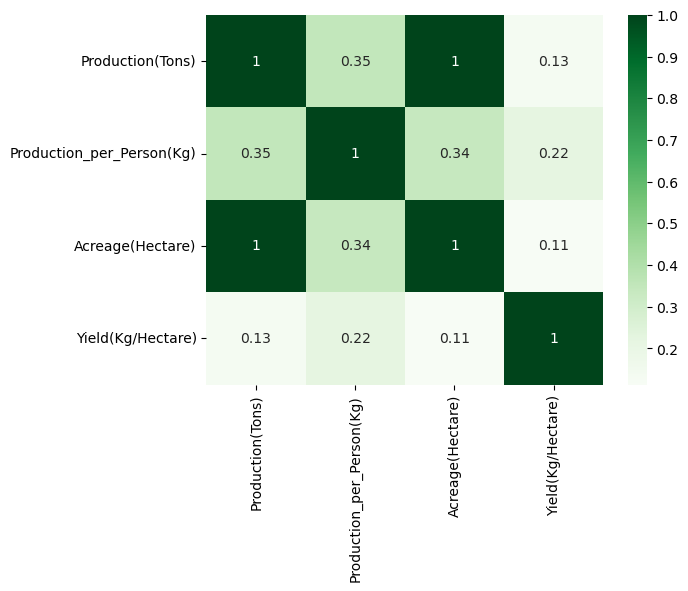

In [31]:
import seaborn as sns
sns.heatmap(corr,annot = True,cmap='Greens')

**Do Countries with the Highest Land Produce More Sugarcane?**

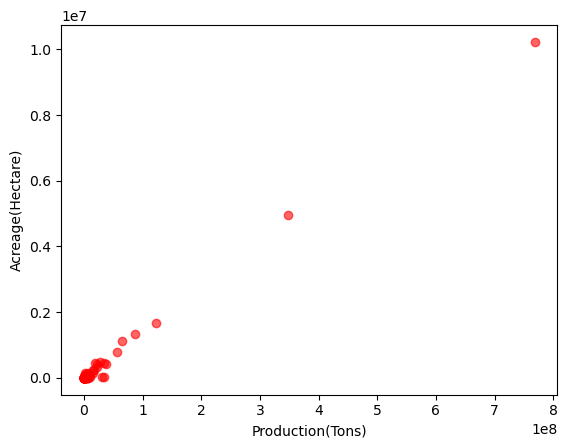

In [32]:
# Answer : Yes
plt.scatter(x=data['Production(Tons)'],y=data['Acreage(Hectare)'],alpha=.6,c='red')
plt.xlabel('Production(Tons)')
plt.ylabel('Acreage(Hectare)')
plt.show()

**Do Countries Yield More Sugarcane per Hectare Produce More Sugarcane in Total?**

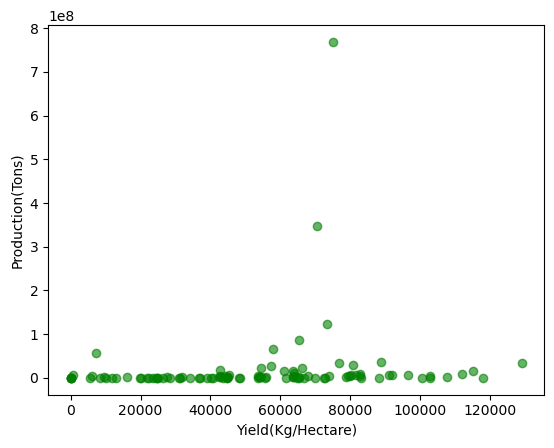

In [33]:
# Answer : No
plt.scatter(x=data['Yield(Kg/Hectare)'],y=data['Production(Tons)'],alpha=.6,c='green')
plt.xlabel('Yield(Kg/Hectare)')
plt.ylabel('Production(Tons)')
plt.show()

# Continental Analysis

In [34]:
df_Continental = data.groupby("Continent").sum().drop('Country',axis=1)

<Axes: xlabel='Continent'>

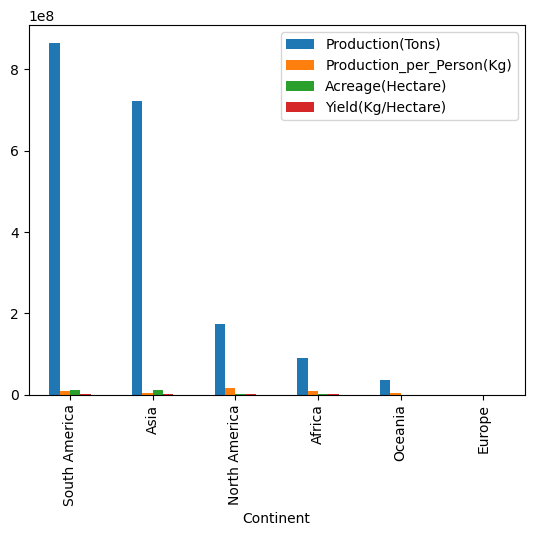

In [35]:
df_Continental.sort_values('Production(Tons)',ascending = False).plot(kind='bar')

**Does the Number of Countries in a Continent Affect Sugarcane Production?**

In [36]:
df_Continental['Number_of_Countries'] = data.groupby('Continent').count()['Country']

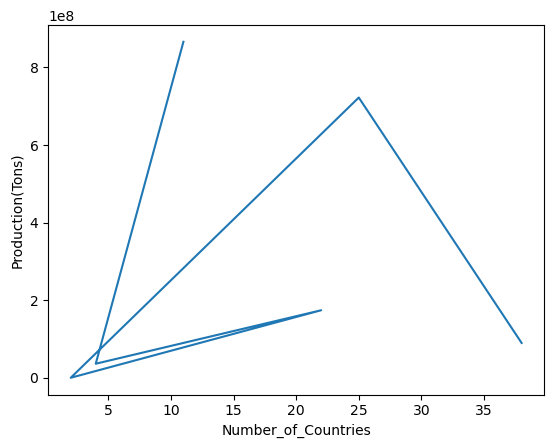

In [37]:
plt.plot(df_Continental['Number_of_Countries'],df_Continental['Production(Tons)'])
plt.xlabel('Number_of_Countries')
plt.ylabel('Production(Tons)')
plt.show()

**Correlation Analysis**

In [38]:
df_Continental.corr()

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare),Number_of_Countries
Production(Tons),1.000000,0.143100,0.994897,0.091201,0.109244
Production_per_Person(Kg),0.143100,1.000000,0.073059,0.541229,0.526387
Acreage(Hectare),0.994897,0.073059,1.000000,0.111166,0.132817
Yield(Kg/Hectare),0.091201,0.541229,0.111166,1.000000,0.989712
Number_of_Countries,0.109244,0.526387,0.132817,0.989712,1.000000


<Axes: >

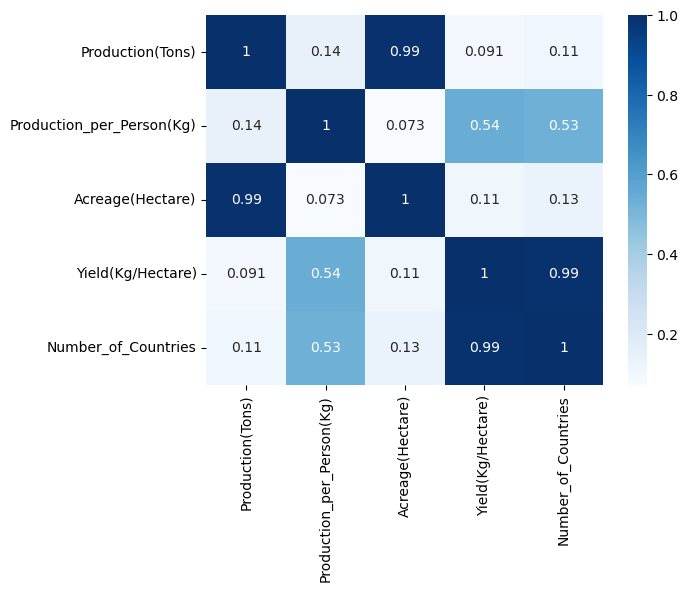

In [39]:
sns.heatmap(df_Continental.corr(),cmap='Blues',annot=True)